# LSTM for Remaining Useful Life (RUL) Prediction

Dataset: NASA C-MAPSS (cleaned)

- Input:  sequences of 30 sensor readings
- Output: predicted RUL
- Loss:   Mean Squared Error between predicted and actual RUL

In this File:
- Created sliding window sequences
- Split data by engine (no data leakage)
- Built 2 layer LSTM with dropout
- Trained with early stopping
- Visualized predictions for individual engines

In [1]:

# Importing required Packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Data Loading and Creating Sliding window Sequence

In [2]:

df = pd.read_csv(r"C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\data\train_FD001_clean.csv")
 
# Define features
sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
setting_cols = [col for col in df.columns if col.startswith('setting_')]
feature_cols = sensor_cols + setting_cols
 
# We'll use RUL_clipped as our target (capped at 125)
SEQUENCE_LENGTH = 30  # Look at 30 consecutive cycles
 
def create_sequences(df, feature_cols, sequence_length):
    """
    For each engine, slide a window of `sequence_length` cycles
    and collect the corresponding RUL at the end of each window.
    
    Returns:
        X: array of shape (num_samples, sequence_length, num_features)
        y: array of shape (num_samples,) — RUL at end of each window
        engine_ids: which engine each sample came from
    """
    X_list = []
    y_list = []
    engine_list = []
    
    for engine_id in df['engine_id'].unique():
        # Get this engine's data (already sorted by cycle)
        engine_data = df[df['engine_id'] == engine_id]
        features = engine_data[feature_cols].values
        rul = engine_data['RUL_clipped'].values
        
        # Skip engines with fewer cycles than our window size
        if len(features) < sequence_length:
            continue
        
        # Slide the window across this engine's lifetime
        for i in range(len(features) - sequence_length + 1):
            X_list.append(features[i : i + sequence_length])
            y_list.append(rul[i + sequence_length - 1])  # RUL at window end
            engine_list.append(engine_id)
    
    return np.array(X_list), np.array(y_list), np.array(engine_list)
 
X, y, engine_ids = create_sequences(df, feature_cols, SEQUENCE_LENGTH)
 
print(f"Total sequences created: {len(X)}")
print(f"Each sequence shape: {X.shape[1:]}  (30 timesteps × {X.shape[2]} features)")
print(f"Target (RUL) range: {y.min()} to {y.max()}")

Total sequences created: 17731
Each sequence shape: (30, 13)  (30 timesteps × 13 features)
Target (RUL) range: 0 to 125


# Train-Test Split by Engine

In [3]:

unique_engines = np.unique(engine_ids)
np.random.seed(42)
np.random.shuffle(unique_engines)
 
# 80% engines for training, 20% for testing
split_point = int(0.8 * len(unique_engines))
train_engines = unique_engines[:split_point]
test_engines = unique_engines[split_point:]
 
train_mask = np.isin(engine_ids, train_engines)
test_mask = np.isin(engine_ids, test_engines)
 
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
test_engine_ids = engine_ids[test_mask]
 
print(f"Train engines: {len(train_engines)} ({len(X_train)} sequences)")
print(f"Test engines:  {len(test_engines)} ({len(X_test)} sequences)")

Train engines: 80 (14020 sequences)
Test engines:  20 (3711 sequences)


# Building the LSTM

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
 
tf.random.set_seed(42)
 
model = keras.Sequential([
    # First LSTM layer — reads the 30-step sequence
    # return_sequences=True means it outputs a value at EVERY timestep
    # (needed because the second LSTM also reads a sequence)
    layers.LSTM(64, return_sequences=True,
                input_shape=(SEQUENCE_LENGTH, len(feature_cols))),
    layers.Dropout(0.2),  # Randomly turn off 20% of neurons (prevents overfitting)
    
    # Second LSTM layer — reads the first LSTM's output
    # return_sequences=False means it only outputs ONE value (the final state)
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    
    # Output layer — predicts a single number (RUL)
    layers.Dense(1)
])
 
model.compile(
    optimizer='adam',
    loss='mse',                # Mean Squared Error
    metrics=['mae']            # Mean Absolute Error (easier to interpret)
)
 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

# Training the Model

In [5]:

# EarlyStopping: stop training if validation loss stops improving
# This prevents overfitting — the model stops before it memorizes training data
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,          # wait 10 epochs before stopping
    restore_best_weights=True  # go back to the best epoch
)
 
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.15,   # 15% of training data for validation
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - loss: 6783.5718 - mae: 71.5151 - val_loss: 6702.4141 - val_mae: 71.1036
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 5806.0288 - mae: 65.3038 - val_loss: 5886.1333 - val_mae: 66.1513
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 5096.2271 - mae: 60.7599 - val_loss: 5193.1636 - val_mae: 61.9021
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 4494.6206 - mae: 56.8779 - val_loss: 4598.6279 - val_mae: 58.2021
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - loss: 3972.5137 - mae: 53.4447 - val_loss: 4087.7295 - val_mae: 54.9708
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 3535.4553 - mae: 50.5529 - val_loss: 3652.0820 - val_mae: 52.1650
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 3168.5955 - mae: 48.1144 - val_loss: 3283.4644 - val_mae: 49.7395
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 2867.3416 - mae: 46.0454 - val_loss: 2974.4590

# Evaluating the Model

In [6]:

# Predict RUL for test data
y_pred = model.predict(X_test, verbose=0).flatten()
 
# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
 
print(f"\nTest Results:")
print(f"  RMSE: {rmse:.2f} cycles")
print(f"  MAE:  {mae:.2f} cycles")
print(f"  R²:   {r2:.4f}")
print(f"\nInterpretation: On average, the model's RUL prediction is")
print(f"off by about {mae:.0f} cycles from the actual value.")


Test Results:
  RMSE: 15.25 cycles
  MAE:  12.26 cycles
  R²:   0.8671

Interpretation: On average, the model's RUL prediction is
off by about 12 cycles from the actual value.


## Training History

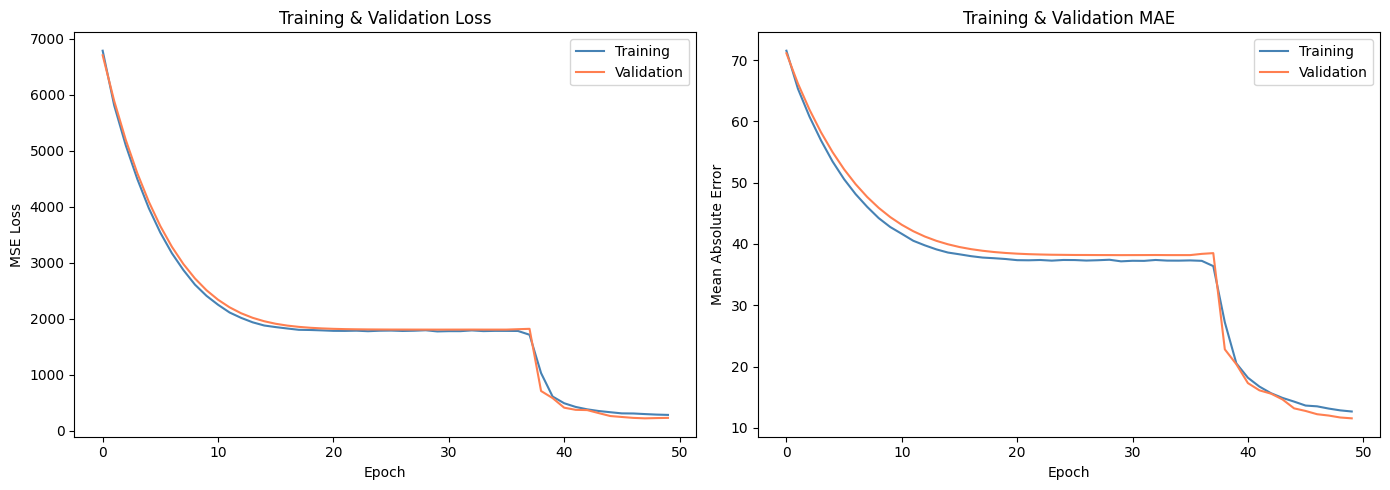

Saved: results/lstm_training_history.png


In [7]:
 
# Plot 1: Training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(history.history['loss'], label='Training', color='steelblue', linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='Validation', color='coral', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
 
axes[1].plot(history.history['mae'], label='Training', color='steelblue', linewidth=1.5)
axes[1].plot(history.history['val_mae'], label='Validation', color='coral', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_title('Training & Validation MAE')
axes[1].legend()
 
plt.tight_layout()
plt.savefig(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\results\lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/lstm_training_history.png")

## Predicted VS Actual RUL

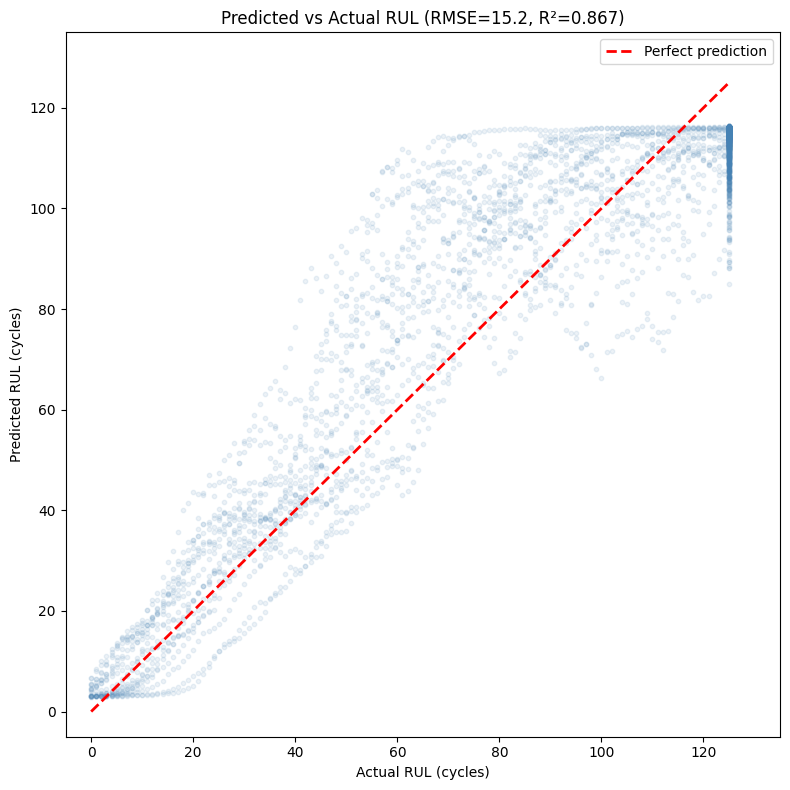

Saved: results/predicted_vs_actual_rul.png


In [8]:

# Plot 2: Predicted vs Actual RUL (scatter plot)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.1, s=10, color='steelblue')
ax.plot([0, 125], [0, 125], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Predicted RUL (cycles)')
ax.set_title(f'Predicted vs Actual RUL (RMSE={rmse:.1f}, R²={r2:.3f})')
ax.legend()
ax.set_xlim(-5, 135)
ax.set_ylim(-5, 135)
plt.tight_layout()
plt.savefig(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\results\predicted_vs_actual_rul.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/predicted_vs_actual_rul.png")

## RUL prediction over time

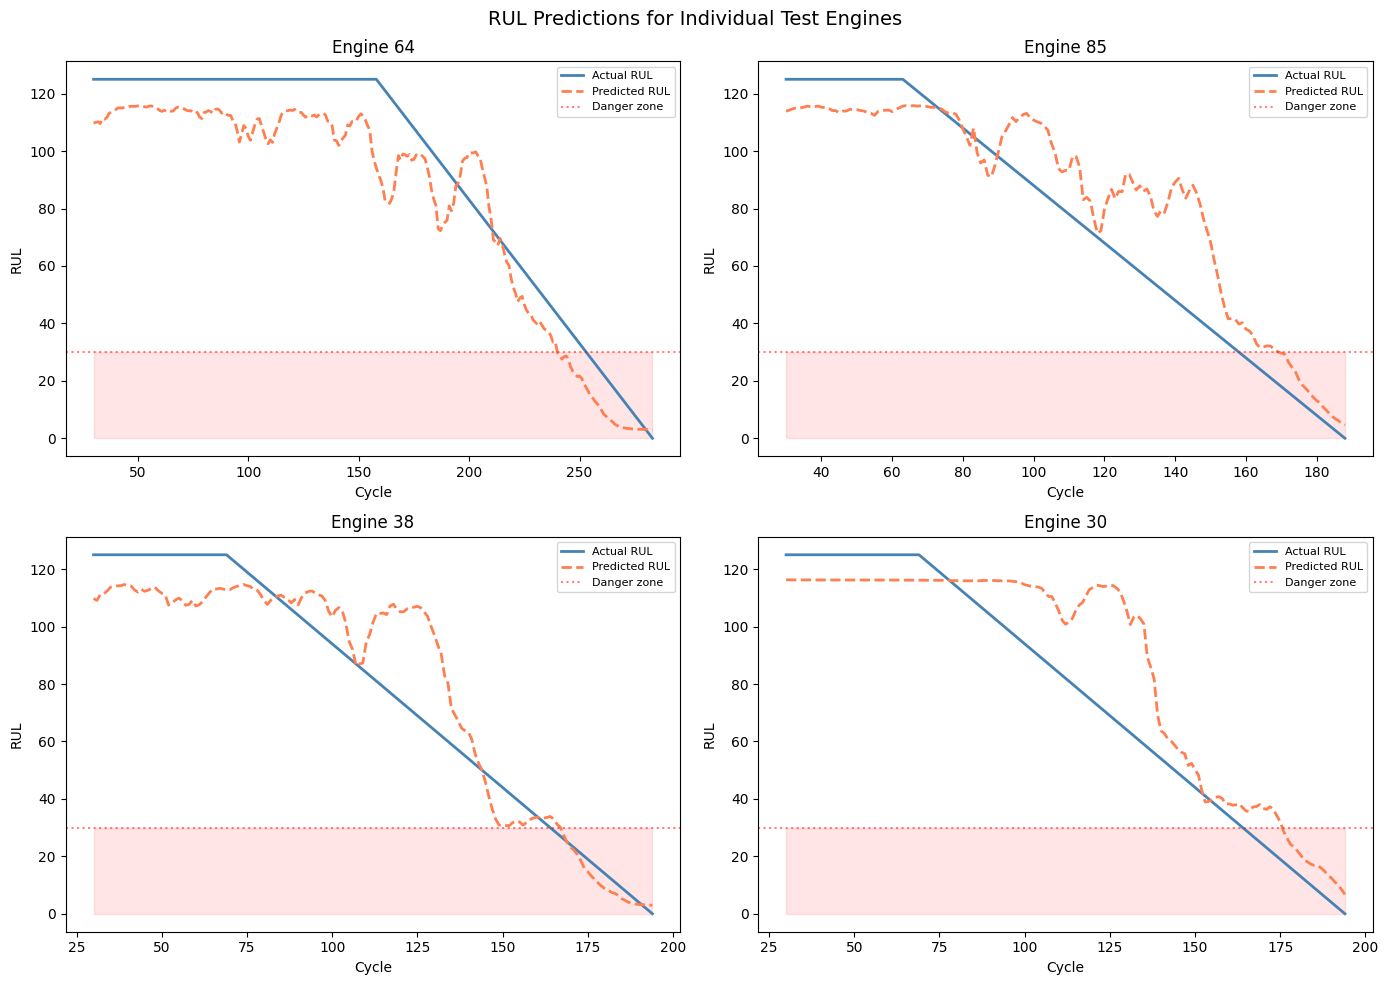

Saved: results/rul_predictions_engines.png


In [9]:
# Plot 3: RUL prediction over time for specific test engines

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RUL Predictions for Individual Test Engines', fontsize=14)
 
# Pick 4 test engines to visualize
sample_engines = test_engines[:4]
 
for idx, eng_id in enumerate(sample_engines):
    ax = axes[idx // 2, idx % 2]
    
    mask = test_engine_ids == eng_id
    actual = y_test[mask]
    predicted = y_pred[mask]
    cycles = np.arange(SEQUENCE_LENGTH, SEQUENCE_LENGTH + len(actual))
    
    ax.plot(cycles, actual, label='Actual RUL', color='steelblue', linewidth=2)
    ax.plot(cycles, predicted, label='Predicted RUL', color='coral',
            linewidth=2, linestyle='--')
    ax.axhline(y=30, color='red', linestyle=':', alpha=0.5, label='Danger zone')
    ax.fill_between(cycles, 0, 30, alpha=0.1, color='red')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('RUL')
    ax.set_title(f'Engine {eng_id}')
    ax.legend(fontsize=8)
 
plt.tight_layout()
plt.savefig(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\results\rul_predictions_engines.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/rul_predictions_engines.png")

## Prediction Error Distribution

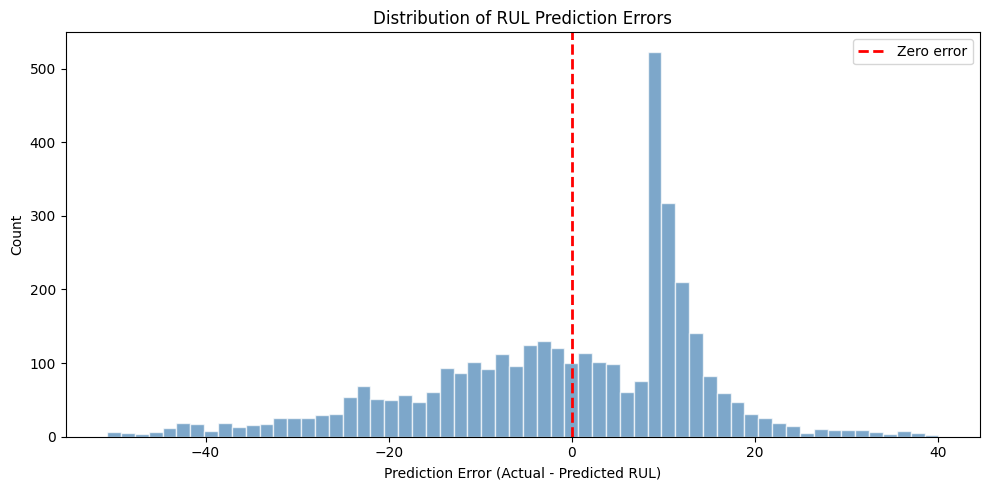

Saved: results/rul_error_distribution.png


In [11]:

errors = y_test - y_pred  # positive = model underestimates danger
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(errors, bins=60, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax.set_xlabel('Prediction Error (Actual - Predicted RUL)')
ax.set_ylabel('Count')
ax.set_title('Distribution of RUL Prediction Errors')
ax.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\results\rul_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/rul_error_distribution.png")

# Saving the Model and Predictions

In [12]:

# Save the LSTM model
model.save(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\data\lstm_rul_model.keras')
print("Saved LSTM model to: data/lstm_rul_model.keras")
 
# Save predictions for decision engine
rul_results = pd.DataFrame({
    'engine_id': test_engine_ids,
    'actual_rul': y_test,
    'predicted_rul': y_pred
})
rul_results.to_csv(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\data\rul_predictions.csv', index=False)
print("Saved predictions to: data/rul_predictions.csv")

Saved LSTM model to: data/lstm_rul_model.keras
Saved predictions to: data/rul_predictions.csv
